# Bound vs unbound antibody torsions

The companion of [`ab_rmsds.ipynb`](ab_rmsds.ipynb), in internal coordinates. Same 16
antibody-antigen cases of the [Protein-Protein Docking Benchmark
5.5](https://zlab.wenglab.org/benchmark/), same bound/unbound residue correspondence -- both
notebooks import it from [`ab_common.py`](ab_common.py) -- but the quantity measured is the
change in backbone and side-chain **torsion angles** instead of the displacement of atoms.

## Why do this at all, given the RMSDs

Torsions are **frame-free**. The whole superposition apparatus of the RMSD notebook -- four
fitting schemes, the elbow effect, `self` versus `fv_fw_ca`, the separation of "displacement"
from "internal change" -- exists only because Cartesian RMSD is meaningless without a
reference frame. A torsion angle needs none: `Delta phi` at IMGT position 105 is the same
number whatever you superpose on, or if you superpose on nothing at all.

That buys two things the RMSDs cannot give:

1. **Locality.** RMSD says *how much* the antibody changed. Torsions say *where the change is
   encoded*. A 3 A loop displacement is either spread over twenty small backbone rotations or
   concentrated in one or two hinge torsions, and those two situations call for completely
   different docking treatments.
2. **Commensurability across cases.** `Delta phi` at IMGT position 105 means the same thing in
   all 16 antibodies, which Cartesian coordinates never do. That is what makes a
   position-resolved average over the whole set meaningful, and it is the input that Part B
   (dihedral PCA) needs.

## What is measured

For every bound/unbound **matched residue pair** (the correspondence of `ab_common`: ANARCII
IMGT numbering inside the Fv, pairwise sequence alignment outside it):

| angle | atoms | defined when |
|---|---|---|
| `phi` | C(i-1) N(i) CA(i) C(i) | residue i-1 is bonded to i |
| `psi` | N(i) CA(i) C(i) N(i+1) | residue i is bonded to i+1 |
| `omega` | CA(i-1) C(i-1) N(i) CA(i) | residue i-1 is bonded to i |
| `chi1`, `chi2` | standard IUPAC atom sets | side chain long enough, same residue type in both |

An angle contributes a difference only when it is defined in **both** structures, so a chain
break on either side removes it. Bonding is decided geometrically (C-N below 2 A), not from
residue numbering, because these are crystal structures with real gaps.

Aggregated over the same **extents** as the RMSD notebook (`fv`, `framework`, `cdr_all`,
`H1`..`L3`, `full`, `interface10`, `interface5`) and over **angle sets** (`bb` = phi+psi,
`bb_om` = +omega, `chi` = chi1+chi2, `all`), reported as:

* `rms_deg` -- root mean square of the wrapped differences, in degrees
* `chord` -- `sqrt(mean(2(1-cos d)))`, the periodicity-safe alternative that a single 179 deg
  flip cannot dominate
* `max_deg`, `p90_deg` -- the tail, which is where the hinges live
* `n_flip60` -- backbone rotations past 60 deg, i.e. genuine conformational switches

plus, per position rather than per extent, Ramachandran basin and `chi1` rotamer-bin changes
(section 5).

## Caveats, stated up front

* **No frame means no elbow correction and no correction of any other kind.** This is the
  point, but it cuts both ways: torsions are blind to rigid-body rearrangement. An antibody
  whose VH/VL packing angle changes by 10 degrees with no torsion change at all looks
  *identical* here and very different in `ab_rmsds.ipynb`. The two notebooks are complements,
  not alternatives.
* **Torsion differences do not add up to a displacement.** A single 30 deg rotation at the
  stem of CDR-H3 moves the tip much further than the same 30 deg at the tip. Sections 8 and 9
  measure that lever arm rather than assuming it.
* **Crystallographic side-chain naming is not always resolved.** The two methyls of Val and
  Leu, and the two oxygens of Asp, are chemically equivalent, so `chi` differences involving
  them are only defined up to the naming convention. Symmetric terminal groups are folded to
  their true period and swappable ones are resolved to the smaller difference; both are
  flagged and counted, and the unresolved values are kept alongside.
* **Chi angles need the same residue type on both sides**, so the mutated positions (one
  inside the Fv, ten over the full chains) contribute backbone but no side-chain differences.
* Everything the RMSD notebook warns about upstream still applies: 4FQI's missing
  assembly-generated antigen chains, and 5VPG standing in for the benchmark's 3RVW.

In [1]:
import json
import os
import warnings
from math import degrees
from pathlib import Path

# The notebook writes relative paths, so it has to run from the notebooks directory. A kernel
# started at the repository root instead is common enough to be worth handling here.
NB_DIR = Path.cwd()
if not (NB_DIR / 'data' / '0_base').is_dir():
    alt = NB_DIR / 'biobb_wf_antibody' / 'notebooks'
    if (alt / 'data' / '0_base').is_dir():
        os.chdir(alt)
        NB_DIR = Path.cwd()
        print(f'chdir -> {NB_DIR}')
    else:
        raise RuntimeError(f'kernel cwd {NB_DIR} does not contain data/0_base')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import ab_common as ab
from ab_common import BENCHMARK, imgt_region, res_key

from biobb_common import biobb_global_properties

biobb_global_properties.update({
    'out_log_path': 'log/log.out',
    'err_log_path': 'log/log.err',
    'remove_tmp': True,
    'can_write_console_log': False,
})

OUT = Path('data') / 'torsions'
RES = OUT / 'results'
FIG = OUT / 'figures'
RMSD_RES = Path('data') / 'rmsds' / 'results'      # written by ab_rmsds.ipynb
for d in (RES, FIG, Path('log')):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.width', 200, 'display.max_columns', 60)
warnings.filterwarnings('ignore', category=UserWarning, module='Bio.PDB')

print('cwd        :', NB_DIR)
print('output dir :', OUT)
print('pandas     :', pd.__version__)

cwd        : /home/rchaves/repo/biobb/biobb_wf_antibody/biobb_wf_antibody/notebooks
output dir : data/torsions
pandas     : 2.3.3


## 1. Cases

`ab_common.build_cases()` is sections 1-5 of `ab_rmsds.ipynb`, extracted verbatim: fetch the
32 entries, clean the chains with `pdb_tools`, IMGT-renumber with ANARCII, build the
bound/unbound residue correspondence, and flag the interface residues. It reads and writes the
same `data/rmsds/prep` directory, so nothing is recomputed and -- more importantly -- both
notebooks measure the identical residue pairs.

In [2]:
cases, tables = ab.build_cases()

display(tables['case'][['case_idx', 'ref', 'unb', 'difficulty', 'benchmark_irmsd', 'chain_map',
                        'chain_types', 'n_fv', 'n_full', 'n_iface10', 'n_mutations']]
        .set_index('case_idx'))
print(f'{len(cases)} cases prepared')
assert len(cases) == 16
for _, row in tables['case'].iterrows():
    if row['warnings']:
        print(f'  [case {row["case_idx"]} {row["ref"]}] {row["warnings"]}')

16 cases prepared
  [case 1 2W9E_HL:A] slot 0 (H vs H): sequence identity 0.977
  [case 7 4FQI_HL:ABEFCD] antigen chains E,F,C,D absent from 4FQI


,ref,unb,difficulty,benchmark_irmsd,chain_map,chain_types,n_fv,n_full,n_iface10,n_mutations
case_idx,,,,,,,,,,
0,2VXT_HL:I,2VXU_HL,rigid,1.33,"H->H,L->L","H,K",217,417,74,0
1,2W9E_HL:A,2W9D_HL,rigid,1.13,"H->H,L->L","H,K",221,425,66,6
2,3EOA_LH:I,3EO9_LH,rigid,0.39,"L->L,H->H","K,H",228,427,51,0
3,3HMX_LH:AB,3HMW_LH,rigid,0.73,"L->L,H->H","K,H",226,431,72,3
4,3MXW_LH:A,3MXV_LH,rigid,0.48,"L->L,H->H","K,H",225,431,70,0
5,5VPG_CD:A,3RVT_CD,rigid,0.50,"C->C,D->D","K,H",228,429,50,0
6,4DN4_LH:M,4DN3_LH,rigid,0.81,"L->L,H->H","K,H",226,424,56,0
7,4FQI_HL:ABEFCD,4FQH_HL,rigid,1.08,"H->H,L->L","H,L",227,423,44,0
8,4G6J_HL:A,4G5Z_HL,rigid,0.61,"H->H,L->L","H,K",225,430,71,0


## 2. Torsion definitions

Backbone angles need the neighbouring residue, so the first thing to establish is which
residues are actually bonded. Residue numbering cannot answer that in a crystal structure --
3V6F has consecutively numbered residues 3.16 A apart -- so the peptide bond is detected
geometrically.

Side-chain atom sets are the IUPAC ones. Two kinds of degeneracy are handled explicitly:

* `CHI_PERIOD` -- a terminal group with a genuine two-fold symmetry (the carboxylate of Asp,
  the ring of Phe and Tyr) makes its chi angle defined modulo 180 deg, not 360 deg.
* `CHI_SWAP` -- the two methyls of Val and Leu are chemically equivalent but *not* related by
  a 180 deg rotation, so no period fixes them. Their chi is defined only relative to which
  atom the depositor called CG1/CD1. These are resolved pairwise, by taking whichever naming
  gives the smaller difference, and every row where that mattered is flagged.

In [17]:
# The atom-set tables, the periodicity/equivalence tables and dihedral() itself live in
# ab_common, because ab_ensemble.py needs exactly the same definitions to featurise MD frames.
# Two copies of the chi1 atom set would silently invalidate any comparison between the two.
from ab_common import (ALL_ANGLES, BB_ANGLES, CHI1_LAST, CHI2_ATOMS, CHI_ANGLES, CHI_PERIOD,
                       CHI_SWAP, PEPTIDE_BOND_MAX, dihedral, wrap)


def _xyz(residue, name):
    return residue[name].coord if name in residue else None


def bonded(prev_res, res) -> bool:
    """True if prev_res and res are joined by a peptide bond (geometry, not numbering)."""
    c, n = _xyz(prev_res, 'C'), _xyz(res, 'N')
    if c is None or n is None:
        return False
    return float(np.linalg.norm(c - n)) < PEPTIDE_BOND_MAX


def chi_quads(residue, alt: bool = False) -> dict:
    """ab_common.chi_quads, taking a Bio.PDB Residue instead of a residue name."""
    return ab.chi_quads(residue.get_resname(), alt=alt)


def structure_torsions(pdb_path) -> dict:
    """{res_key: {angle: degrees}} for every residue of a prepared PDB file.

    Also returns the alternative naming of the swappable chi angles under
    '<angle>_alt', so the pairwise comparison can choose between them.
    """
    out = {}
    for _chain_id, (_seq, residues) in ab.observed_residues(pdb_path).items():
        for i, res in enumerate(residues):
            prev_res = residues[i - 1] if i > 0 else None
            next_res = residues[i + 1] if i + 1 < len(residues) else None
            has_prev = prev_res is not None and bonded(prev_res, res)
            has_next = next_res is not None and bonded(res, next_res)
            angles = {}

            quads = {}
            if has_prev:
                quads['phi'] = [(prev_res, 'C'), (res, 'N'), (res, 'CA'), (res, 'C')]
                quads['omega'] = [(prev_res, 'CA'), (prev_res, 'C'), (res, 'N'), (res, 'CA')]
            if has_next:
                quads['psi'] = [(res, 'N'), (res, 'CA'), (res, 'C'), (next_res, 'N')]
            for alt in (False, True):
                for angle, names in chi_quads(res, alt=alt).items():
                    quads[angle + ('_alt' if alt else '')] = [(res, n) for n in names]

            for angle, spec in quads.items():
                coords = [_xyz(r, n) for r, n in spec]
                if any(c is None for c in coords):
                    continue
                angles[angle] = dihedral(*coords)
            out[res_key(res)] = angles
    return out


tor = {}
for idx, ctx in cases.items():
    for which in ('ref', 'unb'):
        path = ctx['paths'][f'{which}_ab']
        tor[str(path)] = structure_torsions(path)
        ctx[f'{which}_tor'] = tor[str(path)]

cov_rows = []
for idx, ctx in cases.items():
    for which in ('ref', 'unb'):
        t = ctx[f'{which}_tor']
        row = {'case': idx, 'which': which, 'n_res': len(t)}
        for angle in ALL_ANGLES:
            row[angle] = sum(angle in v for v in t.values())
        cov_rows.append(row)
cov = pd.DataFrame(cov_rows)
display(cov.groupby('which').sum(numeric_only=True).drop(columns='case'))
print('residues per structure : %d-%d' % (cov.n_res.min(), cov.n_res.max()))
print('phi defined for        : %.1f%% of residues' % (100 * cov.phi.sum() / cov.n_res.sum()))
print('psi defined for        : %.1f%% of residues' % (100 * cov.psi.sum() / cov.n_res.sum()))
print('chi1 defined for       : %.1f%% of residues' % (100 * cov.chi1.sum() / cov.n_res.sum()))
print('(phi/psi are missing at chain termini and either side of every unmodelled gap;')
print(' chi1 is undefined for Gly and Ala by construction)')

residues per structure : 419-440
phi defined for        : 99.3% of residues
psi defined for        : 99.3% of residues
chi1 defined for       : 86.1% of residues
(phi/psi are missing at chain termini and either side of every unmodelled gap;
 chi1 is undefined for Gly and Ala by construction)


,n_res,phi,psi,omega,chi1,chi2
which,,,,,,
ref,6885,6839,6839,6839,5925,3586
unb,6896,6851,6851,6851,5943,3596


## 3. Circular differences

`wrap(d, period)` maps a difference into the half-open interval centred on zero, which is the
only correct way to subtract two angles: the naive `a - b` reports a rotation from -179 deg to
+179 deg as 358 deg instead of 2 deg. Every summary statistic below operates on wrapped
values.

Two summaries are reported for each group, because they fail differently:

* `rms_deg` is in degrees and is what a reader expects, but it is quadratic, so one hinge flip
  in a 60-residue loop dominates it.
* `chord` = `sqrt(mean(2(1-cos d)))` saturates at 2 for antiparallel angles, so it measures
  *how many* torsions changed rather than how far the worst one went.

Reporting both makes the distinction between a distributed and a localised change visible in
the table itself: a loop with a large `rms_deg` and a small `chord` has one hinge.

In [18]:
def pair_deltas(ctx: dict, pairs, keyed: bool):
    """Per-residue, per-angle differences for a list of matched pairs.

    `pairs` is either [(slot, imgt_key, ref_res, unb_res)] (keyed=True) or
    [(slot, ref_res, unb_res)]. Returns a list of row dicts, one per defined angle.
    """
    ref_tor, unb_tor = ctx['ref_tor'], ctx['unb_tor']
    rows = []
    for item in pairs:
        if keyed:
            slot, key, r, u = item
        else:
            slot, r, u = item
            key = None
        rt, ut = ref_tor.get(res_key(r), {}), unb_tor.get(res_key(u), {})
        same_type = r.get_resname().upper() == u.get_resname().upper()
        region = imgt_region(key[0]) if key else ''
        heavy = ctx['slot_is_heavy'][slot]
        base = {
            'case_idx': ctx['case_idx'], 'unb_code': ctx['unb_code'], 'slot': slot,
            'chain_type': 'H' if heavy else 'L',
            'imgt_num': key[0] if key else np.nan, 'imgt_icode': key[1] if key else '',
            'region': region,
            'cdr': ('H' if heavy else 'L') + region[-1] if region.startswith('CDR') else '',
            'resname_bound': r.get_resname(), 'resname_unbound': u.get_resname(),
            'mutated': not same_type,
            'in_iface10': res_key(r) in ctx['interface10'],
            'in_iface5': res_key(r) in ctx['interface5'],
            'ref_key': str(res_key(r)), 'unb_key': str(res_key(u)),
        }
        for angle in ALL_ANGLES:
            if angle not in rt or angle not in ut:
                continue
            if angle in CHI_ANGLES and not same_type:
                continue                    # a chi difference across a mutation is meaningless
            resname = r.get_resname().upper()
            period = CHI_PERIOD.get((resname, angle), 360.0)
            d_raw = float(wrap(rt[angle] - ut[angle], period))
            # equivalent-atom naming: take the smaller of the two definitions, and say so
            d = d_raw
            swapped = False
            alt = angle + '_alt'
            if (resname, angle) in CHI_SWAP and alt in ut:
                d_alt = float(wrap(rt[angle] - ut[alt], period))
                if abs(d_alt) < abs(d_raw):
                    d, swapped = d_alt, True
            rows.append({**base, 'angle': angle,
                         'val_bound': float(rt[angle]), 'val_unbound': float(ut[angle]),
                         'delta': d, 'delta_raw': d_raw, 'abs_delta': abs(d),
                         'period': period, 'sym_resolved': swapped})
    return rows


delta_rows, full_rows = [], []
for idx, ctx in cases.items():
    delta_rows += pair_deltas(ctx, ctx['imgt_pairs'], keyed=True)
    full_rows += pair_deltas(ctx, ctx['full_pairs'], keyed=False)

dfd = pd.DataFrame(delta_rows)          # IMGT-keyed: the position-resolved table
dffull = pd.DataFrame(full_rows)        # every matched residue, Fv or constant domain

print(f'{len(dfd)} IMGT-keyed angle differences, {len(dffull)} over the full chains')
print('per angle:', dict(dfd.angle.value_counts()))
print('chi rows resolved by equivalent-atom swap: %d of %d (%.1f%%)'
      % (int(dfd.sym_resolved.sum()), int(dfd.angle.isin(CHI_ANGLES).sum()),
         100 * dfd.sym_resolved.sum() / max(1, dfd.angle.isin(CHI_ANGLES).sum())))
print('period-180 chi rows (Asp/Phe/Tyr chi2)  :', int((dfd.period == 180).sum()))
print('mutated matched positions: %d inside the Fv, %d over the full chains'
      % (dfd[dfd.mutated].ref_key.nunique(), dffull[dffull.mutated].ref_key.nunique()))
print('  (backbone differences are kept there, chi differences are not)')
display(dfd.groupby('angle')['abs_delta'].describe().round(2))

# The geometric bonding test is not a formality. In the unbound 3V6F, residues numbered 52 and
# 53 are 3.16 A apart -- an unmodelled break that consecutive numbering hides completely. Trusting
# the numbering would have invented a phi and an omega for IMGT position 58 out of two
# unconnected chain fragments.
brk = 0
for idx, ctx in cases.items():
    for which in ('ref', 'unb'):
        for _cid, (_seq, residues) in ab.observed_residues(ctx['paths'][f'{which}_ab']).items():
            for a, b in zip(residues, residues[1:]):
                if a.id[1] + 1 == b.id[1] and not bonded(a, b):
                    brk += 1
print(f'\nconsecutively numbered residue pairs that are NOT bonded: {brk}')
print('(each one would have produced a fabricated phi/psi had numbering been trusted)')

15832 IMGT-keyed angle differences, 29892 over the full chains
per angle: {'psi': np.int64(3618), 'omega': np.int64(3586), 'phi': np.int64(3586), 'chi1': np.int64(3066), 'chi2': np.int64(1976)}
chi rows resolved by equivalent-atom swap: 45 of 5042 (0.9%)
period-180 chi rows (Asp/Phe/Tyr chi2)  : 507
mutated matched positions: 1 inside the Fv, 10 over the full chains
  (backbone differences are kept there, chi differences are not)

consecutively numbered residue pairs that are NOT bonded: 5
(each one would have produced a fabricated phi/psi had numbering been trusted)


,count,mean,std,min,25%,50%,75%,max
angle,,,,,,,,
chi1,3066.0,19.37,33.77,0.00,2.61,6.29,15.03,178.49
chi2,1976.0,19.67,32.01,0.01,2.84,7.24,18.30,179.24
omega,3586.0,3.48,5.27,0.00,0.99,2.30,4.75,172.79
phi,3586.0,9.17,16.00,0.00,2.31,5.11,10.48,179.12
psi,3618.0,9.05,17.01,0.00,2.19,4.96,9.60,179.88


## 4. Extents, angle sets and per-case summaries

The extents are the RMSD notebook's, so the two result tables can be joined case by case and
extent by extent. What replaces its (atom set x superposition scheme) grid is a single
**angle set** axis -- there is no scheme axis, which is the whole advantage of working in
internal coordinates.

`n_flip60` counts backbone angles past 60 deg. The threshold is conventional rather than
derived: 60 deg is roughly the separation between adjacent Ramachandran basins, so a rotation
that large has almost certainly changed basin rather than jiggled within one. Section 5
reports basin changes directly, which is the assumption-free version of the same statistic.

In [19]:
EXTENTS = ['fv', 'framework', 'cdr_all', 'H1', 'H2', 'H3', 'L1', 'L2', 'L3',
           'full', 'interface10', 'interface5']
ANGLE_SETS = {'bb': ('phi', 'psi'), 'bb_om': ('phi', 'psi', 'omega'),
              'chi': ('chi1', 'chi2'), 'chi1': ('chi1',), 'all': ALL_ANGLES}
FLIP_DEG = 60.0
MIN_ANGLES = 4          # below this a summary statistic is not worth reporting


def extent_mask(d: pd.DataFrame, extent: str) -> pd.Series:
    """Boolean mask selecting the rows of one extent from a delta table."""
    if extent == 'fv':
        return d.imgt_num.notna()
    if extent == 'framework':
        return d.region == 'FR'
    if extent == 'cdr_all':
        return d.region.str.startswith('CDR')
    if extent == 'full':
        return pd.Series(True, index=d.index)
    if extent in ('interface10', 'interface5'):
        return d[f'in_iface{extent[9:]}']
    if len(extent) == 2 and extent[0] in 'HL' and extent[1] in '123':
        return d.cdr == extent
    raise KeyError(extent)


def summarise(d: pd.DataFrame, angles) -> dict:
    """Circular summary statistics for one group of angle differences."""
    sel = d[d.angle.isin(angles)]
    n = len(sel)
    if n == 0:
        return {'n_angles': 0, 'n_res': 0, 'status': 'no_angles'}
    delta = sel.delta.to_numpy()
    absd = np.abs(delta)
    rad = np.radians(delta * (360.0 / sel.period.to_numpy()))   # rescale so a period-180
    bb = sel[sel.angle.isin(('phi', 'psi'))]                    # angle spans the full circle
    return {
        'n_angles': n, 'n_res': sel.ref_key.nunique(),
        'rms_deg': float(np.sqrt(np.mean(delta ** 2))),
        'mad_deg': float(np.mean(absd)),
        'median_deg': float(np.median(absd)),
        'p90_deg': float(np.percentile(absd, 90)),
        'max_deg': float(np.max(absd)),
        'chord': float(np.sqrt(np.mean(2 * (1 - np.cos(rad))))),
        'n_flip60': int((np.abs(bb.delta) > FLIP_DEG).sum()),
        'frac_flip60': float((np.abs(bb.delta) > FLIP_DEG).mean()) if len(bb) else np.nan,
        'status': 'ok' if n >= MIN_ANGLES else 'too_few_angles',
    }


rows = []
for idx, ctx in cases.items():
    bench = BENCHMARK[ctx['unb_code']]
    meta = {'case_idx': idx, 'ref': ctx['ref'], 'unb': ctx['unb'],
            'ref_code': ctx['ref_code'], 'unb_code': ctx['unb_code'],
            'difficulty': bench[1], 'benchmark_irmsd': bench[2], 'benchmark_dasa': bench[3],
            'iface_partial': ctx['iface_partial']}
    d_imgt = dfd[dfd.case_idx == idx]
    d_full = dffull[dffull.case_idx == idx]
    for extent in EXTENTS:
        d = d_full if extent in ('full', 'interface10', 'interface5') else d_imgt
        sub = d[extent_mask(d, extent)]
        for aset, angles in ANGLE_SETS.items():
            rows.append({**meta, 'extent': extent, 'angle_set': aset,
                         **summarise(sub, angles)})

dft = pd.DataFrame(rows)
dft.to_csv(RES / 'ab_torsions_long.csv', index=False)


def pick(extent, angle_set='bb', stat='rms_deg') -> pd.Series:
    sel = dft[(dft.extent == extent) & (dft.angle_set == angle_set)]
    return sel.set_index('case_idx')[stat]


print(f'{len(dft)} summary rows ({len(EXTENTS)} extents x {len(ANGLE_SETS)} angle sets x '
      f'{len(cases)} cases) | statuses: {dict(dft.status.value_counts())}')
display(dft[(dft.angle_set == 'bb')
            & (dft.extent.isin(['framework', 'cdr_all', 'H3', 'interface10']))]
        .pivot_table(index='case_idx', columns='extent',
                     values=['rms_deg', 'max_deg', 'n_flip60']).round(1))

960 summary rows (12 extents x 5 angle sets x 16 cases) | statuses: {'ok': np.int64(933), 'too_few_angles': np.int64(27)}


max_deg                               n_flip60                               rms_deg                              
extent        H3 cdr_all framework interface10       H3 cdr_all framework interface10      H3 cdr_all framework interface10
case_idx                                                                                                                   
0           15.6    26.5     166.3        26.5      0.0     0.0       6.0         0.0     7.1     8.6      17.1         7.9
1           49.3   167.7      76.7       167.7      0.0     9.0       3.0         7.0    19.9    39.2      14.1        29.7
2          102.7   102.7     175.8       102.7      2.0     2.0       4.0         2.0    31.1    18.3      17.9        17.3
3          109.4   109.4     170.2       109.4      2.0     4.0       3.0         5.0    32.0    25.2      18.1        22.4
4           17.8    22.1      75.6        75.6      0.0     0.0       3.0         1.0     9.8     7.3       9.4         9.6
5           14.2    20.2     176.1        18.5      0.0     0.0       4.0         0.0     7.6     7.8      18.7         7.6
6           25.4   148.9      91.1       148.9      0.0     7.0       1.0         5.0     9.2    32.5      13.4        28.0
7           33.2    40.8     134.6        40.8      0.0     0.0       3.0         0.0    10.2    12.0      12.6        13.4
8           29.4    33.8     105.7       105.7      0.0     0.0       1.0         1.0    10.5     9.1      10.2        12.5
9           12.9    14.4     165.8       165.8      0.0     0.0       2.0         1.0     5.3     5.1      12.9        16.2
10          33.1   179.1      35.7        33.1      0.0     3.0       0.0         0.0    12.6    25.6       6.2         8.8
11          38.0   172.9     156.0       171.9      0.0    19.0       6.0        19.0    18.8    61.4      22.3        49.7
12          50.2    50.2      75.1        50.2      0.0     0.0       1.0         0.0    15.3    12.2      14.6        13.3
13         179.6   179.6     137.9       179.6      6.0     8.0       4.0        10.0    68.5    38.2      14.9        34.1
14          22.7    43.4     167.1        43.4      0.0     0.0       3.0         0.0     9.9    10.8      16.4        10.8
15         170.9   179.9     176.7       179.9      7.0    13.0       6.0        13.0    63.4    48.6      18.9        43.9

## 5. Conformational switches: Ramachandran basins and chi1 rotamers

`rms_deg` is a continuous measure and treats a 20 deg relaxation the same way as the first
20 deg of a basin hop. For docking what matters is the discrete question -- did this residue
change *state*? Two coarse state assignments answer it without a threshold on the difference:

* A four-way Ramachandran partition of (phi, psi). It is deliberately crude; its only job is
  to separate the right-handed helical region, the beta region, and the left-handed region
  that glycines and a few CDR residues occupy.
* The three chi1 rotamer bins, `g+` (0-120 deg), `t` (120-240 deg), `g-` (240-360 deg), the
  standard partition of side-chain rotamer libraries.

A residue that changes either state has genuinely moved to a different conformer, and that is
the population a docking protocol must either sample or get wrong.

In [20]:
def rama_basin(phi, psi) -> str:
    """Coarse (phi, psi) basin: 'alphaR' | 'beta' | 'alphaL' | 'other'."""
    if phi is None or psi is None or np.isnan(phi) or np.isnan(psi):
        return ''
    if phi < 0:
        return 'alphaR' if -120.0 < psi <= 50.0 else 'beta'
    return 'alphaL' if -50.0 < psi <= 100.0 else 'other'


def rotamer_bin(chi1) -> str:
    """chi1 rotamer bin: 'g+' | 't' | 'g-'."""
    if chi1 is None or np.isnan(chi1):
        return ''
    x = chi1 % 360.0
    return 'g+' if x < 120.0 else ('t' if x < 240.0 else 'g-')


state_rows = []
for idx, ctx in cases.items():
    for slot, key, r, u in ctx['imgt_pairs']:
        rt, ut = ctx['ref_tor'].get(res_key(r), {}), ctx['unb_tor'].get(res_key(u), {})
        region = imgt_region(key[0])
        heavy = ctx['slot_is_heavy'][slot]
        same_type = r.get_resname().upper() == u.get_resname().upper()
        rb_b = rama_basin(rt.get('phi'), rt.get('psi'))
        rb_u = rama_basin(ut.get('phi'), ut.get('psi'))
        ro_b = rotamer_bin(rt.get('chi1')) if same_type else ''
        ro_u = rotamer_bin(ut.get('chi1')) if same_type else ''
        state_rows.append({
            'case_idx': idx, 'unb_code': ctx['unb_code'], 'chain_type': 'H' if heavy else 'L',
            'imgt_num': key[0], 'imgt_icode': key[1], 'region': region,
            'cdr': ('H' if heavy else 'L') + region[-1] if region.startswith('CDR') else '',
            'resname': r.get_resname(), 'mutated': not same_type,
            'in_iface10': res_key(r) in ctx['interface10'],
            'in_iface5': res_key(r) in ctx['interface5'],
            'basin_bound': rb_b, 'basin_unbound': rb_u,
            'basin_change': bool(rb_b and rb_u and rb_b != rb_u),
            'basin_comparable': bool(rb_b and rb_u),
            'rot_bound': ro_b, 'rot_unbound': ro_u,
            'rot_change': bool(ro_b and ro_u and ro_b != ro_u),
            'rot_comparable': bool(ro_b and ro_u),
        })

dfs = pd.DataFrame(state_rows)
dfs.to_csv(RES / 'ab_torsions_states.csv', index=False)

by_region = dfs.groupby('region').agg(
    n=('imgt_num', 'size'),
    basin_comparable=('basin_comparable', 'sum'), basin_changes=('basin_change', 'sum'),
    rot_comparable=('rot_comparable', 'sum'), rot_changes=('rot_change', 'sum'))
by_region['basin_pct'] = 100 * by_region.basin_changes / by_region.basin_comparable
by_region['rot_pct'] = 100 * by_region.rot_changes / by_region.rot_comparable
display(by_region.round(1))

iface = dfs[dfs.in_iface10]
print('Ramachandran basin changes: %d of %d comparable positions (%.1f%%)'
      % (dfs.basin_change.sum(), dfs.basin_comparable.sum(),
         100 * dfs.basin_change.sum() / dfs.basin_comparable.sum()))
print('chi1 rotamer changes      : %d of %d comparable positions (%.1f%%)'
      % (dfs.rot_change.sum(), dfs.rot_comparable.sum(),
         100 * dfs.rot_change.sum() / dfs.rot_comparable.sum()))
print('within the 10 A interface : %.1f%% basin, %.1f%% rotamer'
      % (100 * iface.basin_change.sum() / iface.basin_comparable.sum(),
         100 * iface.rot_change.sum() / iface.rot_comparable.sum()))
print('per case, interface rotamer changes:',
      dict(iface[iface.rot_change].groupby('unb_code').size().sort_values(ascending=False)))

Ramachandran basin changes: 85 of 3577 comparable positions (2.4%)
chi1 rotamer changes      : 382 of 3066 comparable positions (12.5%)
within the 10 A interface : 4.3% basin, 15.9% rotamer
per case, interface rotamer changes: {'3EO0': np.int64(18), '3HI5': np.int64(16), '3HMW': np.int64(14), '4FQH': np.int64(13), '3V6F': np.int64(11), '2W9D': np.int64(11), '3G6A': np.int64(8), '4DN3': np.int64(8), '4G6K': np.int64(6), '3RVT': np.int64(6), '2VXU': np.int64(6), '3MXV': np.int64(5), '4GXV': np.int64(5), '3EO9': np.int64(4), '3L7E': np.int64(4), '4G5Z': np.int64(4)}


,n,basin_comparable,basin_changes,rot_comparable,rot_changes,basin_pct,rot_pct
region,,,,,,,
CDR1,239,238,14,200,32,5.9,16.0
CDR2,172,170,11,142,24,6.5,16.9
CDR3,351,343,19,300,47,5.5,15.7
FR,2865,2826,41,2424,279,1.5,11.5


### Peptide flips

The largest single backbone differences in the whole set are not loop rearrangements. They are
**peptide flips**: `psi(i)` and `phi(i+1)` rotate by about 180 deg in opposite directions, the
two rotations cancel, and the only atom that really moves is the carbonyl oxygen. They are
partly genuine and partly a refinement ambiguity -- at 2 A resolution the carbonyl direction is
often not determined by the density -- and either way they are the *wrong* thing to build a
docking protocol around: no rigid-body or loop-sampling treatment cares where a backbone
carbonyl points, and a flip is not a hinge.

They have to be found before the hinge candidates of section 9 can be trusted, and they are
recognisable by their signature: both rotations past 120 deg, and `d psi(i) + d phi(i+1)`
close to zero. The pairing is taken from the covalent structure, not from consecutive IMGT
numbers, because a matched position's IMGT successor is not always its bonded neighbour.

In [21]:
FLIP_MIN = 120.0        # both rotations must be at least this large
CANCEL_MAX = 60.0       # ... and must cancel to within this


def bonded_next(pdb_path) -> dict:
    """{res_key: next Residue} for every residue that has a bonded successor."""
    out = {}
    for _cid, (_seq, residues) in ab.observed_residues(pdb_path).items():
        for a, b in zip(residues, residues[1:]):
            if bonded(a, b):
                out[res_key(a)] = b
    return out


def peptide_flips(ctx: dict) -> list:
    """Correlated psi(i)/phi(i+1) rotations across matched, covalently bonded residue pairs."""
    ref_next = bonded_next(ctx['paths']['ref_ab'])
    unb_next = bonded_next(ctx['paths']['unb_ab'])
    partner = {res_key(r): u for _s, _k, r, u in ctx['imgt_pairs']}
    rows = []
    for slot, key, r, u in ctx['imgt_pairs']:
        rn, un = ref_next.get(res_key(r)), unb_next.get(res_key(u))
        if rn is None or un is None:
            continue
        mate = partner.get(res_key(rn))
        if mate is None or res_key(mate) != res_key(un):
            continue        # the two successors are not each other's counterpart: not comparable
        rt, ut = ctx['ref_tor'][res_key(r)], ctx['unb_tor'][res_key(u)]
        rt2, ut2 = ctx['ref_tor'][res_key(rn)], ctx['unb_tor'][res_key(un)]
        if 'psi' not in rt or 'psi' not in ut or 'phi' not in rt2 or 'phi' not in ut2:
            continue
        d_psi = float(wrap(rt['psi'] - ut['psi']))
        d_phi = float(wrap(rt2['phi'] - ut2['phi']))
        cancel = float(wrap(d_psi + d_phi))
        region = imgt_region(key[0])
        rows.append({
            'case_idx': ctx['case_idx'], 'unb_code': ctx['unb_code'],
            'chain_type': 'H' if ctx['slot_is_heavy'][slot] else 'L',
            'imgt_num': key[0], 'imgt_icode': key[1], 'region': region,
            'resname': r.get_resname(), 'd_psi': d_psi, 'd_phi_next': d_phi, 'cancel': cancel,
            'ref_key': str(res_key(r)), 'ref_key_next': str(res_key(rn)),
            'is_flip': abs(d_psi) > FLIP_MIN and abs(d_phi) > FLIP_MIN
                       and abs(cancel) < CANCEL_MAX,
        })
    return rows


dff = pd.DataFrame([row for ctx in cases.values() for row in peptide_flips(ctx)])
dff.to_csv(RES / 'ab_torsions_flips.csv', index=False)
flips = dff[dff.is_flip]

# mark, in the per-angle table, every angle that belongs to a detected flip
flip_psi = {(r.case_idx, r.ref_key) for r in flips.itertuples()}
flip_phi = {(r.case_idx, r.ref_key_next) for r in flips.itertuples()}
dfd['in_flip'] = [((c, k) in flip_psi and a == 'psi') or ((c, k) in flip_phi and a == 'phi')
                  for c, k, a in zip(dfd.case_idx, dfd.ref_key, dfd.angle)]
dfd.to_csv(RES / 'ab_torsions_imgt.csv', index=False)

big = dfd[dfd.angle.isin(('phi', 'psi')) & (dfd.abs_delta > FLIP_MIN)]
print('peptide flips detected            : %d over the 16 cases' % len(flips))
print('backbone rotations past %.0f deg    : %d, of which %d belong to a flip (%.0f%%)'
      % (FLIP_MIN, len(big), int(big.in_flip.sum()),
         100 * big.in_flip.mean() if len(big) else 0))
print('flips inside a CDR                : %d of %d' % ((flips.region != 'FR').sum(), len(flips)))
display(flips[['case_idx', 'unb_code', 'chain_type', 'imgt_num', 'region', 'resname',
               'd_psi', 'd_phi_next', 'cancel']].round(1).set_index(['case_idx', 'unb_code']))
print('flips per case:', dict(flips.groupby('unb_code').size().sort_values(ascending=False)))
print('\nThis is why the CDR numbers of case 11 (3EO0) have to be read carefully: most of its')
print('extreme CDR rotations are flips, so its loops have changed far less than rms_deg says.')

peptide flips detected            : 14 over the 16 cases
backbone rotations past 120 deg    : 56, of which 28 belong to a flip (50%)
flips inside a CDR                : 7 of 14
flips per case: {'3EO0': np.int64(5), '3HI5': np.int64(2), '3V6F': np.int64(2), '3RVT': np.int64(2), '3EO9': np.int64(1), '3L7E': np.int64(1), '3HMW': np.int64(1)}

This is why the CDR numbers of case 11 (3EO0) have to be read carefully: most of its
extreme CDR rotations are flips, so its loops have changed far less than rms_deg says.


chain_type  imgt_num region resname  d_psi  d_phi_next  cancel
case_idx unb_code                                                               
2        3EO9              L        92     FR     SER  175.8      -151.4    24.4
3        3HMW              L        46     FR     PRO  145.5      -170.2   -24.7
5        3RVT              L        92     FR     SER -163.6       144.0   -19.6
         3RVT              H        46     FR     PRO -161.5       176.1    14.6
11       3EO0              L        29   CDR1     LEU  153.0      -149.0     4.0
         3EO0              L        56   CDR2     GLY -140.4       123.4   -17.1
         3EO0              L        57   CDR2     ALA  172.9      -162.1    10.7
         3EO0              H        58   CDR2     PRO -158.4       129.9   -28.5
         3EO0              H        72     FR     LYS -145.0       138.0    -6.9
13       3HI5              H       108   CDR3     TYR  179.6       122.2   -58.2
         3HI5              H       112   CDR3     SER -153.9      -163.0    43.1
14       3L7E              L        92     FR     SER -167.1       159.1    -8.0
15       3V6F              H       112   CDR3     SER  154.2      -141.6    12.6
         3V6F              L        69     FR     SER -161.8      -176.7    21.4

## 6. Verification

Four independent checks, the same structure as section 8 of `ab_rmsds.ipynb`.

In [22]:
# --- Check 1: identity ---------------------------------------------------------------------
# Compare the bound antibody with itself. observed_residues() is memoised per path, so both
# sides resolve to the same Residue objects and every difference must be exactly zero.
id_rows = []
for idx, ctx in cases.items():
    fake = dict(ctx)
    fake['unb_tor'] = ctx['ref_tor']
    pairs = [(slot, key, r, r) for slot, key, r, _u in ctx['imgt_pairs']]
    rows = pair_deltas(fake, pairs, keyed=True)
    worst = max((abs(r['delta']) for r in rows), default=0.0)
    id_rows.append({'case': idx, 'n_angles': len(rows), 'max_abs_delta': worst})
id_df = pd.DataFrame(id_rows)
print('Check 1  identity: %d angles, worst |delta| = %.3e deg'
      % (id_df.n_angles.sum(), id_df.max_abs_delta.max()))
assert id_df.max_abs_delta.max() < 1e-6, id_df[id_df.max_abs_delta >= 1e-6]

Check 1  identity: 15855 angles, worst |delta| = 0.000e+00 deg


In [23]:
# --- Check 2: independent implementation ----------------------------------------------------
# mdtraj computes phi/psi/chi1/chi2 with its own topology and its own geometry code. Both halves
# of our implementation are checked against it separately, because they fail differently:
#   (a) the geometry -- evaluate our dihedral() on mdtraj's own atom quadruples;
#   (b) the atom selection -- compare the *sets* of quadruples the two codes chose.
# Quadruples are keyed by atom index into the file, which is exact. (Keying on rounded
# coordinates instead looks tempting and silently loses a quarter of the matches: mdtraj holds
# float32 nanometres, so a coordinate written as 12.345 A comes back as 12.34499., and the two
# land on opposite sides of the rounding boundary.)
import mdtraj as md

MDT = {'phi': md.compute_phi, 'psi': md.compute_psi,
       'chi1': md.compute_chi1, 'chi2': md.compute_chi2}


def flat_atoms(pdb_path):
    """Atoms of a prepared file in file order, and id(atom) -> index into that order."""
    atoms = [a for _cid, (_seq, residues) in ab.observed_residues(pdb_path).items()
             for r in residues for a in r]
    return atoms, {id(a): i for i, a in enumerate(atoms)}


def our_quads(pdb_path, index) -> dict:
    """{angle: {(i0, i1, i2, i3): value}} from our own selection, keyed by atom index."""
    out = {a: {} for a in MDT}
    for _chain_id, (_seq, residues) in ab.observed_residues(pdb_path).items():
        for i, res in enumerate(residues):
            prev_res = residues[i - 1] if i > 0 else None
            next_res = residues[i + 1] if i + 1 < len(residues) else None
            spec = {}
            if prev_res is not None and bonded(prev_res, res):
                spec['phi'] = [(prev_res, 'C'), (res, 'N'), (res, 'CA'), (res, 'C')]
            if next_res is not None and bonded(res, next_res):
                spec['psi'] = [(res, 'N'), (res, 'CA'), (res, 'C'), (next_res, 'N')]
            for angle, names in chi_quads(res).items():
                spec[angle] = [(res, n) for n in names]
            for angle, quad in spec.items():
                if any(n not in r for r, n in quad):
                    continue
                atoms = [r[n] for r, n in quad]
                out[angle][tuple(index[id(a)] for a in atoms)] = dihedral(
                    *[a.coord for a in atoms])
    return out


md_rows, order_mismatch = [], 0
for idx, ctx in cases.items():
    for which in ('ref', 'unb'):
        path = str(ctx['paths'][f'{which}_ab'])
        t = md.load(path)
        xyz = t.xyz[0] * 10.0                      # nm -> A
        atoms, index = flat_atoms(path)
        # the index keys only mean the same thing in both codes if the atom order agrees
        md_names = [a.name for a in t.topology.atoms]
        if len(md_names) != len(atoms) or any(
                m != a.get_name().strip() for m, a in zip(md_names, atoms)):
            order_mismatch += 1
            continue
        ours = our_quads(path, index)
        for angle, fn in MDT.items():
            indices, values = fn(t)
            theirs = {tuple(int(i) for i in quad): float(np.degrees(v))
                      for quad, v in zip(indices, values[0])}
            common = set(ours[angle]) & set(theirs)
            geom = max((abs(float(wrap(dihedral(*xyz[quad]) - np.degrees(v))))
                        for quad, v in zip(indices, values[0])), default=0.0)
            val = max((abs(float(wrap(ours[angle][k] - theirs[k]))) for k in common), default=0.0)
            md_rows.append({'case': idx, 'which': which, 'angle': angle,
                            'n_ours': len(ours[angle]), 'n_mdtraj': len(theirs),
                            'n_common': len(common),
                            'only_ours': len(set(ours[angle]) - set(theirs)),
                            'only_mdtraj': len(set(theirs) - set(ours[angle])),
                            'max_geom_diff': geom, 'max_value_diff': val})
mdf = pd.DataFrame(md_rows)
display(mdf.groupby('angle').agg(n_ours=('n_ours', 'sum'), n_mdtraj=('n_mdtraj', 'sum'),
                                 n_common=('n_common', 'sum'),
                                 only_ours=('only_ours', 'sum'),
                                 only_mdtraj=('only_mdtraj', 'sum'),
                                 max_geom_diff=('max_geom_diff', 'max'),
                                 max_value_diff=('max_value_diff', 'max')))
print('atom-order mismatches :', order_mismatch, 'of', 2 * len(cases), 'files')
print('Check 2a geometry     : worst disagreement on mdtraj\'s own quadruples = %.1e deg'
      % mdf.max_geom_diff.max())
print('Check 2b shared quads : worst value disagreement = %.1e deg' % mdf.max_value_diff.max())
print('Check 2c selection    : %d quadruples only ours, %d only mdtraj\'s'
      % (mdf.only_ours.sum(), mdf.only_mdtraj.sum()))
print('  the residual is float32: mdtraj stores nanometres in single precision, which is ~1e-3')
print('  deg on an angle. Anything above ~0.01 deg would be a real disagreement.')
assert order_mismatch == 0
assert mdf.max_geom_diff.max() < 0.01
assert mdf.max_value_diff.max() < 0.01
# Selection differences are expected in one direction only: mdtraj bonds consecutive residues
# from its residue templates, so it computes phi/psi across unmodelled gaps where we refuse to.
extra = mdf.groupby('angle')[['only_ours', 'only_mdtraj']].sum()
print('\nselection differences per angle (0 for chi, gaps only affect the backbone):')
display(extra)
assert extra.loc[['chi1', 'chi2']].to_numpy().sum() == 0, 'side-chain selections must agree exactly'
assert extra.only_ours.sum() == 0, 'we should never select a quadruple mdtraj rejects'

atom-order mismatches : 0 of 32 files
Check 2a geometry     : worst disagreement on mdtraj's own quadruples = 6.9e-04 deg
Check 2b shared quads : worst value disagreement = 1.1e-03 deg
Check 2c selection    : 0 quadruples only ours, 54 only mdtraj's
  the residual is float32: mdtraj stores nanometres in single precision, which is ~1e-3
  deg on an angle. Anything above ~0.01 deg would be a real disagreement.

selection differences per angle (0 for chi, gaps only affect the backbone):


,n_ours,n_mdtraj,n_common,only_ours,only_mdtraj,max_geom_diff,max_value_diff
angle,,,,,,,
chi1,11868,11868,11868,0,0,0.000595,0.000941
chi2,7182,7182,7182,0,0,0.000694,0.000991
phi,13690,13717,13690,0,27,0.000614,0.001078
psi,13690,13717,13690,0,27,0.000677,0.001014


,only_ours,only_mdtraj
angle,,
chi1,0,0
chi2,0,0
phi,0,27
psi,0,27


In [24]:
# --- Check 3: periodicity -------------------------------------------------------------------
# Every difference and every summary statistic must be invariant under adding a full turn to any
# angle of either structure. This is the check that catches the classic dihedral bug: a naive
# a - b turns a 2 deg rotation across the +-180 deg branch cut into a 358 deg one.
rng = np.random.default_rng(0)
shift_rows = []
for idx, ctx in cases.items():
    shifted = {k: {a: v + 360.0 * rng.integers(-2, 3) for a, v in angles.items()}
               for k, angles in ctx['unb_tor'].items()}
    fake = dict(ctx)
    fake['unb_tor'] = shifted
    base = pd.DataFrame(pair_deltas(ctx, ctx['imgt_pairs'], keyed=True))
    pert = pd.DataFrame(pair_deltas(fake, ctx['imgt_pairs'], keyed=True))
    assert len(base) == len(pert)
    d = np.abs(base.delta.to_numpy() - pert.delta.to_numpy()).max()
    s_base = summarise(base[base.region.str.startswith('CDR')], ANGLE_SETS['bb'])
    s_pert = summarise(pert[pert.region.str.startswith('CDR')], ANGLE_SETS['bb'])
    shift_rows.append({'case': idx, 'max_delta_change': d,
                       'rms_change': abs(s_base['rms_deg'] - s_pert['rms_deg']),
                       'chord_change': abs(s_base['chord'] - s_pert['chord']),
                       'flip_change': abs(s_base['n_flip60'] - s_pert['n_flip60'])})
sh = pd.DataFrame(shift_rows)
print('Check 3  periodicity: worst change under random whole-turn shifts')
print('  per-angle delta %.2e deg | cdr rms %.2e deg | chord %.2e | flip count %d'
      % (sh.max_delta_change.max(), sh.rms_change.max(), sh.chord_change.max(),
         int(sh.flip_change.max())))
assert sh.max_delta_change.max() < 1e-9 and int(sh.flip_change.max()) == 0

Check 3  periodicity: worst change under random whole-turn shifts
  per-angle delta 2.27e-13 deg | cdr rms 1.42e-14 deg | chord 1.11e-16 | flip count 0


In [25]:
# --- Check 4: consistency with ab_rmsds.ipynb ------------------------------------------------
# The two notebooks measure the same structures with disjoint machinery, so one implies the
# other in a direction that can be tested: a segment whose torsions did not change cannot have
# changed internal shape. Concretely, per CDR loop, the backbone self-fit RMSD from
# ab_rmsds.ipynb must be small wherever the backbone torsion rms from this notebook is small.
rmsd_long = pd.read_csv(RMSD_RES / 'ab_rmsds_long.csv')


def rmsd_pick(extent, atom_set='bb', scheme='self') -> pd.Series:
    sel = rmsd_long[(rmsd_long.extent == extent) & (rmsd_long.atom_set == atom_set)
                    & (rmsd_long.scheme == scheme)]
    return sel.set_index('case_idx')['rmsd']


cmp_rows = []
for extent in ('H1', 'H2', 'H3', 'L1', 'L2', 'L3', 'framework'):
    tor_rms = pick(extent, 'bb', 'rms_deg')
    car_rms = rmsd_pick(extent, 'bb', 'self')
    for case in tor_rms.index:
        if not np.isnan(tor_rms[case]) and not np.isnan(car_rms.get(case, np.nan)):
            cmp_rows.append({'case': case, 'extent': extent,
                             'torsion_rms_deg': tor_rms[case], 'bb_self_rmsd': car_rms[case]})
cmpdf = pd.DataFrame(cmp_rows)
rho, p = stats.spearmanr(cmpdf.torsion_rms_deg, cmpdf.bb_self_rmsd)
quiet = cmpdf[cmpdf.torsion_rms_deg < 5.0]
print('Check 4  cross-notebook: %d (loop, case) pairs' % len(cmpdf))
print('  Spearman(torsion rms, backbone self RMSD) = %.3f  (p = %.1e)' % (rho, p))
print('  segments with torsion rms < 5 deg: n = %d, backbone self RMSD max = %.3f A'
      % (len(quiet), quiet.bb_self_rmsd.max() if len(quiet) else np.nan))
assert rho > 0.6, 'the two notebooks disagree about which segments changed'
assert quiet.empty or quiet.bb_self_rmsd.max() < 0.6

Check 4  cross-notebook: 96 (loop, case) pairs
  Spearman(torsion rms, backbone self RMSD) = 0.863  (p = 1.3e-29)
  segments with torsion rms < 5 deg: n = 5, backbone self RMSD max = 0.166 A


## 7. Where the change sits

The position-resolved view that Cartesian coordinates cannot give: IMGT position on the x
axis, mean |Delta| over the 16 cases on the y axis, heavy and light chain separately. Because
the x axis is an IMGT position rather than a residue index, averaging over 16 different
antibodies is a legitimate operation.

Peptide flips are excluded from the profile. They are large, they are localised, and leaving
them in would put a spike on whichever position happened to flip in one structure.

the 15 IMGT positions with the largest mean backbone change, seen in >= 8 cases:

the positions excluded for being rare -- CDR-length-dependent insertions, mostly, where
a "mean over cases" would be an average over one or two structures:
IMGT position 1 and the last matched position of each chain are chain termini. Large
changes there are crystallographic disorder, not a response to binding; they are left in
the profile but should not be read as hinges.


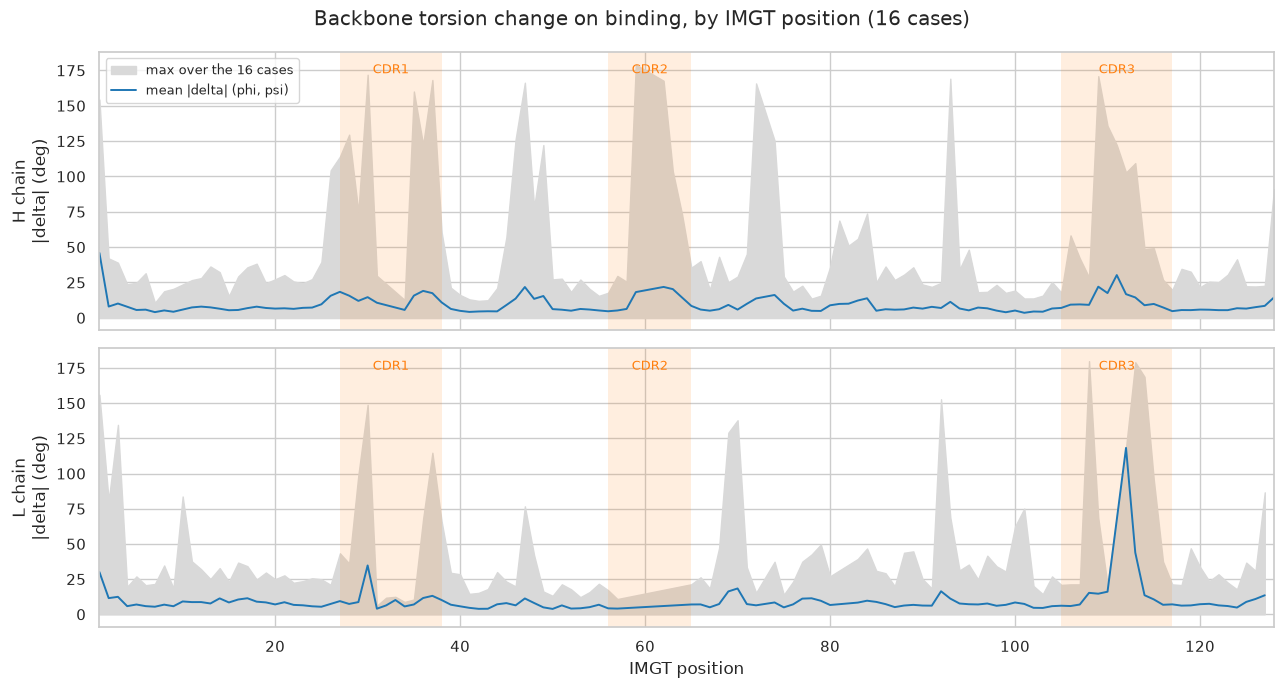

mean_abs  max_abs  n_cases region
chain_type imgt_num                                   
H          1             45.9    154.4       12     FR
           111           30.2    122.2        9   CDR3
L          1             30.0    156.0       12     FR
H          109           22.0    170.9       15   CDR3
           62            21.9    167.7       12   CDR2
           47            21.8    166.3       16     FR
           63            20.3    103.6       16   CDR2
           36            19.0    122.4       16   CDR1
           27            18.4    114.0       16   CDR1
L          70            18.4    137.9       16     FR
H          59            18.2    179.1       16   CDR2
           110           17.5    135.8       14   CDR3
           37            17.4    168.2       16   CDR1
           112           16.7    102.8       12   CDR3
L          92            16.4    152.8       16     FR

mean_abs  max_abs  n_cases region
chain_type imgt_num                                   
L          112          118.2    118.4        1   CDR3
           113           43.9    179.1        5   CDR3
           30            34.7    148.9        5   CDR1
           110           16.1     20.8        2   CDR3
H          31            10.7     29.7        3   CDR1

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
bb = dfd[dfd.angle.isin(('phi', 'psi')) & ~dfd.in_flip]
for ax, chain_type in zip(axes, ('H', 'L')):
    sub = bb[bb.chain_type == chain_type]
    prof = sub.groupby('imgt_num')['abs_delta'].agg(['mean', 'max', 'size'])
    ax.fill_between(prof.index, 0, prof['max'], color='0.85', label='max over the 16 cases')
    ax.plot(prof.index, prof['mean'], color='tab:blue', lw=1.4, label='mean |delta| (phi, psi)')
    for lo, hi in ab.IMGT_CDRS:
        ax.axvspan(lo, hi, color='tab:orange', alpha=0.13, lw=0)
    for lo, hi in ab.IMGT_CDRS:
        ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.92, f'CDR{ab.IMGT_CDRS.index((lo, hi)) + 1}',
                ha='center', fontsize=9, color='tab:orange')
    ax.set_ylabel(f'{chain_type} chain\n|delta| (deg)')
    ax.set_xlim(1, 128)
axes[0].legend(loc='upper left', fontsize=9)
axes[1].set_xlabel('IMGT position')
fig.suptitle('Backbone torsion change on binding, by IMGT position (16 cases)')
fig.tight_layout()
fig.savefig(FIG / 'torsion_profile_imgt.png', dpi=150)
plt.show()

MIN_CASES = 8       # half the set; below this a "mean over cases" is one structure's opinion

prof = (bb.groupby(['chain_type', 'imgt_num'])
        .agg(mean_abs=('abs_delta', 'mean'), max_abs=('abs_delta', 'max'),
             n_cases=('case_idx', 'nunique'), region=('region', 'first')))
print(f'the 15 IMGT positions with the largest mean backbone change, seen in >= {MIN_CASES} cases:')
display(prof[prof.n_cases >= MIN_CASES].sort_values('mean_abs', ascending=False).head(15).round(1))
rare = prof[prof.n_cases < MIN_CASES].sort_values('mean_abs', ascending=False).head(5).round(1)
print('\nthe positions excluded for being rare -- CDR-length-dependent insertions, mostly, where')
print('a "mean over cases" would be an average over one or two structures:')
display(rare)
print('IMGT position 1 and the last matched position of each chain are chain termini. Large')
print('changes there are crystallographic disorder, not a response to binding; they are left in')
print('the profile but should not be read as hinges.')

## 8. Torsion change against the published benchmark, and the lever arm

Left: does a torsion-space measure of the interface reproduce the benchmark's Cartesian
I-RMSD ordering? Middle and right: the lever arm. Both panels are the point of the exercise --
the second one especially, because it decides whether "restrain the CDRs" or "sample two hinge
torsions" is the right response to a flexible case.

Spearman against the published I-RMSD, best first:
  if10_rot_changes   rho = +0.71  (p = 0.002)
  cdr_bb_rms         rho = +0.60  (p = 0.015)
  if5_bb_rms         rho = +0.58  (p = 0.019)
  if10_chi_rms       rho = +0.54  (p = 0.031)
  if10_bb_rms        rho = +0.44  (p = 0.086)


,ref_code,unb_code,difficulty,benchmark_irmsd,benchmark_dasa,fv_bb_rms,fw_bb_rms,cdr_bb_rms,cdr_bb_max,cdr_bb_chord,cdr_flips,H3_bb_rms,H3_bb_max,H3_flips,if10_bb_rms,if10_chi_rms,if5_bb_rms,if10_rot_changes,cdr_ca_fw_rmsd,H3_ca_fw_rmsd,H3_bb_self_rmsd
case_idx,,,,,,,,,,,,,,,,,,,,,
2,3EOA,3EO9,rigid,0.39,1272,17.95,17.85,18.32,102.68,0.29,2,31.08,102.68,2,17.31,36.90,26.34,4,0.44,0.48,0.52
4,3MXW,3MXV,rigid,0.48,1696,9.04,9.41,7.34,22.06,0.13,0,9.82,17.79,0,9.57,33.35,8.41,5,0.57,0.75,0.38
14,3L5W,3L7E,medium,0.48,1138,15.36,16.36,10.83,43.37,0.19,0,9.91,22.69,0,10.78,41.90,9.17,4,0.51,0.45,0.34
9,4G6M,4G6K,rigid,0.49,1673,11.72,12.91,5.10,14.42,0.09,0,5.29,12.91,0,16.22,32.45,4.86,6,0.37,0.30,0.20
5,5VPG,3RVT,rigid,0.50,1383,17.01,18.73,7.81,20.15,0.14,0,7.56,14.19,0,7.62,30.50,8.40,6,0.51,0.68,0.28
8,4G6J,4G5Z,rigid,0.61,1893,9.97,10.17,9.15,33.79,0.16,0,10.49,29.43,0,12.48,33.15,11.01,4,0.45,0.43,0.27
3,3HMX,3HMW,rigid,0.73,1841,19.75,18.09,25.20,109.40,0.40,4,32.01,109.40,2,22.41,42.88,21.82,14,0.70,0.47,0.55
10,4GXU,4GXV,rigid,0.78,1830,13.61,6.22,25.63,179.12,0.35,3,12.63,33.06,0,8.77,36.61,10.95,5,0.64,0.80,0.63
6,4DN4,4DN3,rigid,0.81,1317,19.15,13.40,32.50,148.88,0.50,7,9.20,25.38,0,28.02,55.46,37.74,8,1.29,0.42,0.22


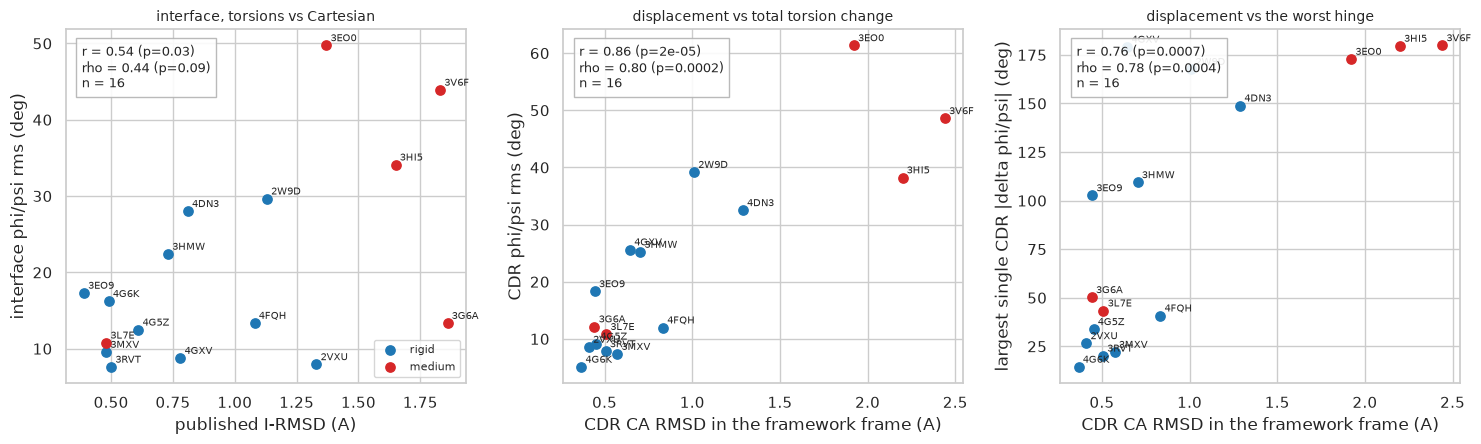

In [27]:
summary = tables['case'].set_index('case_idx')[
    ['ref_code', 'unb_code', 'difficulty', 'benchmark_irmsd', 'benchmark_dasa']].copy()
for label, (extent, aset, stat) in {
        'fv_bb_rms': ('fv', 'bb', 'rms_deg'),
        'fw_bb_rms': ('framework', 'bb', 'rms_deg'),
        'cdr_bb_rms': ('cdr_all', 'bb', 'rms_deg'),
        'cdr_bb_max': ('cdr_all', 'bb', 'max_deg'),
        'cdr_bb_chord': ('cdr_all', 'bb', 'chord'),
        'cdr_flips': ('cdr_all', 'bb', 'n_flip60'),
        'H3_bb_rms': ('H3', 'bb', 'rms_deg'),
        'H3_bb_max': ('H3', 'bb', 'max_deg'),
        'H3_flips': ('H3', 'bb', 'n_flip60'),
        'if10_bb_rms': ('interface10', 'bb', 'rms_deg'),
        'if10_chi_rms': ('interface10', 'chi', 'rms_deg'),
        'if5_bb_rms': ('interface5', 'bb', 'rms_deg'),
}.items():
    summary[label] = pick(extent, aset, stat)
summary['if10_rot_changes'] = dfs[dfs.in_iface10].groupby('case_idx')['rot_change'].sum()
summary['cdr_ca_fw_rmsd'] = rmsd_pick('cdr_all', 'ca', 'fv_fw_ca')
summary['H3_ca_fw_rmsd'] = rmsd_pick('H3', 'ca', 'fv_fw_ca')
summary['H3_bb_self_rmsd'] = rmsd_pick('H3', 'bb', 'self')
summary = summary.sort_values('benchmark_irmsd')
summary.to_csv(RES / 'ab_torsions_summary.csv')
display(summary.round(2))


def annotate(ax, x, y, loc=(0.04, 0.96)):
    ok = np.isfinite(x) & np.isfinite(y)
    r, pr = stats.pearsonr(x[ok], y[ok])
    rho, ps = stats.spearmanr(x[ok], y[ok])
    ax.text(*loc, f'r = {r:.2f} (p={pr:.1g})\nrho = {rho:.2f} (p={ps:.1g})\nn = {ok.sum()}',
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(fc='white', ec='0.7', alpha=0.9))


fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
panels = [('benchmark_irmsd', 'if10_bb_rms', 'published I-RMSD (A)',
           'interface phi/psi rms (deg)', 'interface, torsions vs Cartesian'),
          ('cdr_ca_fw_rmsd', 'cdr_bb_rms', 'CDR CA RMSD in the framework frame (A)',
           'CDR phi/psi rms (deg)', 'displacement vs total torsion change'),
          ('cdr_ca_fw_rmsd', 'cdr_bb_max', 'CDR CA RMSD in the framework frame (A)',
           'largest single CDR |delta phi/psi| (deg)', 'displacement vs the worst hinge')]
for ax, (xc, yc, xl, yl, title) in zip(axes, panels):
    for diff, colour in (('rigid', 'tab:blue'), ('medium', 'tab:red')):
        s = summary[summary.difficulty == diff]
        ax.scatter(s[xc], s[yc], c=colour, label=diff, s=45)
    for _, row in summary.iterrows():
        ax.annotate(row.unb_code, (row[xc], row[yc]), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    annotate(ax, summary[xc].to_numpy(float), summary[yc].to_numpy(float))
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title, fontsize=10)
axes[0].legend(loc='lower right', fontsize=8)
fig.tight_layout()
fig.savefig(FIG / 'torsion_vs_rmsd.png', dpi=150)
plt.show()

print('Spearman against the published I-RMSD, best first:')
for label in ('if10_rot_changes', 'cdr_bb_rms', 'if5_bb_rms', 'if10_chi_rms', 'if10_bb_rms'):
    rho, p = stats.spearmanr(summary.benchmark_irmsd, summary[label])
    print('  %-18s rho = %+.2f  (p = %.3f)' % (label, rho, p))

## 9. Hinges

If loop displacement is carried by a few torsions rather than by all of them, the individual
positions responsible can be named, and a named position is something a biasing protocol can
act on: GROMACS `pull-coord-geometry = dihedral` biases one torsion directly, and `awh1-ndim`
accepts up to four of them.

Peptide flips are excluded here, for the reason given in section 5: a flip moves a carbonyl
oxygen and nothing else, so biasing it would spend an AWH dimension on nothing.

concentration of the CDR backbone torsion change (fraction of sum of squares):
median share carried by the single largest torsion : 16.4%
median share carried by the largest three          : 39.9%

VERDICT. Displacement tracks the total CDR torsion change (rho = +0.80) as well as it
tracks the single worst angle (rho = +0.78). If a few hinges dominated, the second would
clearly win. Together with a median top-3 share of 40%, the change is distributed, not
hinged -- so naming one or two torsions for an AWH dimension is not supported here.


chain_type  imgt_num imgt_icode cdr resname_bound angle  val_bound  val_unbound  abs_delta
case_idx unb_code                                                                                           
0        2VXU              H        62             H2           ASN   psi       -3.3        -29.8       26.5
         2VXU              H        63             H2           GLY   phi       82.8        108.8       26.0
         2VXU              L       109             L3           SER   psi      153.4        131.9       21.6
1        2W9D              H        62             H2           ASN   phi     -143.7         48.6      167.7
         2W9D              H        27             H1           ARG   phi       63.9        -50.1      114.0
         2W9D              H        36             H1           ASP   psi      179.4         65.7      113.8
2        3EO9              H       109             H3           TYR   psi       -7.6         95.1      102.7
         3EO9              H       110             H3           PHE   phi      -60.9       -162.7      101.7
         3EO9              H       112             H3           THR   psi      -82.1       -122.7       40.5
3        3HMW              H       113             H3           GLY   phi      120.3       -130.3      109.4
         3HMW              H        63             H2           SER   psi       65.2        -38.3      103.6
         3HMW              H       112             H3           GLN   psi      -69.2       -172.0      102.8
4        3MXV              L       108             L3           TYR   phi      -68.3        -90.3       22.1
         3MXV              L       114             L3           SER   phi     -108.9        -88.2       20.7
         3MXV              H       115             H3           PHE   phi     -148.8       -131.0       17.8
5        3RVT              L       105             L3           LEU   phi     -143.9       -123.7       20.2
         3RVT              H        59             H2           SER   phi     -102.8        -84.3       18.5
         3RVT              L       108             L3           ASP   psi      -27.8        -44.9       17.1
6        4DN3              L        30             L1           SER   phi      -77.5         71.4      148.9
         4DN3              L        30             L1           SER   psi      -35.0       -161.8      126.8
         4DN3              H        27             H1           GLY   phi      157.4         55.5      101.9
7        4FQH              H        63             H2           GLY   phi       99.7         58.9       40.8
         4FQH              H        62             H2           PHE   phi      -52.3        -92.0       39.7
         4FQH              H        62             H2           PHE   psi      -39.2         -4.3       34.8
8        4G5Z              H        36             H1           VAL   psi        4.6        -29.2       33.8
         4G5Z              H       107             H3           ASP   psi      155.5        126.0       29.4
         4G5Z              H        36             H1           VAL   phi     -112.6        -83.4       29.2
9        4G6K              H        63             H2           GLY   psi       11.5         -2.9       14.4
         4G6K              H        30             H1           LEU   psi      -11.7          2.6       14.3
         4G6K              H       112             H3           PRO   psi      147.6        160.5       12.9
10       4GXV              L       113             L3           SER   phi      -99.5         79.6      179.1
         4GXV              L       112             L3           LEU   phi       52.3        -66.1      118.4
         4GXV              L       112             L3           LEU   psi     -121.8        120.1      118.1
11       3EO0              H        30             H1           PHE   psi      -43.4        128.5      171.9
         3EO0              H        37             H1           ASN   psi      129.1        -3

,unb_code,n_angles,top1,top3,top5,cdr_ca_fw_rmsd
case_idx,,,,,,
0,2VXU,74,0.129,0.338,0.433,0.411
1,2W9D,84,0.218,0.419,0.570,1.010
2,3EO9,96,0.327,0.700,0.763,0.444
3,3HMW,92,0.205,0.569,0.701,0.703
4,3MXV,88,0.103,0.259,0.376,0.572
5,3RVT,96,0.069,0.178,0.265,0.506
6,4DN3,96,0.219,0.480,0.626,1.288
7,4FQH,100,0.116,0.311,0.442,0.833
8,4G5Z,90,0.152,0.380,0.470,0.452


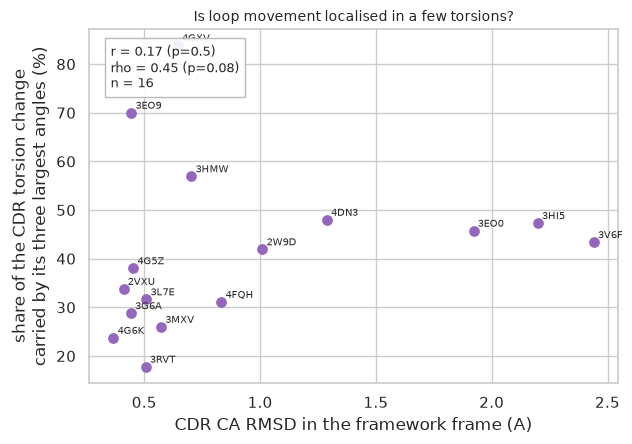

In [28]:
hinge = dfd[dfd.angle.isin(('phi', 'psi')) & dfd.region.str.startswith('CDR')
            & ~dfd.in_flip].copy()
worst = (hinge.sort_values('abs_delta', ascending=False)
         .groupby('case_idx').head(3)
         .loc[:, ['case_idx', 'unb_code', 'chain_type', 'imgt_num', 'imgt_icode', 'cdr',
                  'resname_bound', 'angle', 'val_bound', 'val_unbound', 'abs_delta']]
         .sort_values(['case_idx', 'abs_delta'], ascending=[True, False]))
display(worst.round(1).set_index(['case_idx', 'unb_code']))

# how concentrated is the change? fraction of the summed squared difference carried by the
# largest few torsions of each CDR set
conc_rows = []
for idx in sorted(hinge.case_idx.unique()):
    d = np.sort(hinge[hinge.case_idx == idx].abs_delta.to_numpy() ** 2)[::-1]
    tot = d.sum()
    conc_rows.append({'case_idx': idx, 'unb_code': summary.loc[idx, 'unb_code'],
                      'n_angles': len(d),
                      'top1': d[:1].sum() / tot, 'top3': d[:3].sum() / tot,
                      'top5': d[:5].sum() / tot,
                      'cdr_ca_fw_rmsd': summary.loc[idx, 'cdr_ca_fw_rmsd']})
conc = pd.DataFrame(conc_rows).set_index('case_idx')
print('concentration of the CDR backbone torsion change (fraction of sum of squares):')
display(conc.round(3))
print('median share carried by the single largest torsion : %.1f%%' % (100 * conc.top1.median()))
print('median share carried by the largest three          : %.1f%%' % (100 * conc.top3.median()))

rho_tot = stats.spearmanr(summary.cdr_ca_fw_rmsd, summary.cdr_bb_rms)[0]
rho_max = stats.spearmanr(summary.cdr_ca_fw_rmsd, summary.cdr_bb_max)[0]
print('\nVERDICT. Displacement tracks the total CDR torsion change (rho = %+.2f) as well as it'
      % rho_tot)
print('tracks the single worst angle (rho = %+.2f). If a few hinges dominated, the second would'
      % rho_max)
print('clearly win. Together with a median top-3 share of %.0f%%, the change is distributed, not'
      % (100 * conc.top3.median()))
print('hinged -- so naming one or two torsions for an AWH dimension is not supported here.')

fig, ax = plt.subplots(figsize=(6.5, 4.6))
ax.scatter(conc.cdr_ca_fw_rmsd, 100 * conc.top3, c='tab:purple', s=45)
for idx, row in conc.iterrows():
    ax.annotate(row.unb_code, (row.cdr_ca_fw_rmsd, 100 * row.top3), fontsize=7,
                xytext=(3, 3), textcoords='offset points')
annotate(ax, conc.cdr_ca_fw_rmsd.to_numpy(float), (100 * conc.top3).to_numpy(float))
ax.set_xlabel('CDR CA RMSD in the framework frame (A)')
ax.set_ylabel('share of the CDR torsion change\ncarried by its three largest angles (%)')
ax.set_title('Is loop movement localised in a few torsions?', fontsize=10)
fig.tight_layout()
fig.savefig(FIG / 'torsion_concentration.png', dpi=150)
plt.show()

## 10. Findings

### What binding does to the torsions

* **Almost nothing, almost everywhere.** The median |`Delta phi`| over all 3586 matched
  backbone positions is **5.1 deg** and the median |`Delta chi1`| is **6.3 deg** -- at or below
  the coordinate error of a 2 A structure. Only **51** CDR backbone rotations out of 1499 pass
  60 deg once peptide flips are removed, and they sit in **8 of the 16 cases**. Half the set
  has no CDR backbone rotation past 60 deg at all.
* **Side chains change state ~4x more often than backbones.** 12.5% of comparable positions
  change `chi1` rotamer bin against 2.4% that change Ramachandran basin; inside the 10 A
  interface, 15.9% against 4.3%. Rotamer changes are also the only measure that is clearly
  enriched in the CDRs relative to the framework (16-17% vs 11.5%).
* **Peptide flips are half of the extreme tail.** 28 of the 56 backbone rotations past 120 deg
  belong to one of 14 detected `psi(i)`/`phi(i+1)` flip pairs. They move a carbonyl oxygen and
  nothing else. Case 11 (3EO0) carries 5 of them, three inside CDR-L1/CDR-L2, which is why its
  `cdr_bb_rms` of 61 deg -- the largest in the set -- overstates what its loops actually did.

### What predicts the benchmark's difficulty

Against the published I-RMSD (n = 16, Spearman):

| measure | rho | p |
|---|---|---|
| interface `chi1` rotamer changes | **+0.71** | 0.002 |
| CDR `phi`/`psi` rms | +0.60 | 0.015 |
| 5 A interface `phi`/`psi` rms | +0.58 | 0.019 |
| 10 A interface `chi` rms | +0.54 | 0.031 |
| 10 A interface `phi`/`psi` rms | +0.44 | 0.086 |

**Counting interface rotamer changes predicts the benchmark's Cartesian difficulty better than
any backbone measure here.** That is a concrete, cheap docking heuristic: it needs no
superposition and no frame, just the two structures and a rotamer bin.

### The lever arm: the prediction that failed

The hypothesis this notebook was built to test was that CDR displacement is carried by a few
hinge torsions, so that naming them would give a one- or two-dimensional AWH coordinate.
**The data do not support it.**

* Displacement correlates with the *total* CDR torsion change (`rho = +0.80`) essentially as
  well as with the *single worst* angle (`rho = +0.78`). If a few hinges dominated, the second
  should clearly beat the first.
* The single largest torsion carries a median **16%** of a case's summed squared CDR change and
  the largest three carry **40%**. That is a distributed change, not a hinge.
* Concentration does not rise with displacement (`rho = +0.45`, `p = 0.08`): the cases that
  move most are not the cases whose movement is most localised.

So the tidy conclusion is not available, and the honest consequence is that **a 1-2 dihedral
AWH coordinate is not justified by these 16 cases.** Reproducing the observed loop changes
needs of order ten backbone torsions, which is past what `awh1-ndim` (max 4) can bias and past
what `pull-coord-geometry = dihedral` can express. Whether a *collective* coordinate -- a
linear combination, i.e. Part B -- concentrates the change better is now the open question,
and it is the right reason to do Part B rather than a decorative one.

### For the AWH work

1. **The current COM-distance AWH coordinate is not obviously the wrong choice.** Loop backbone
   plasticity in this benchmark is small and distributed; there is no single torsion whose
   biasing would buy much.
2. **Side-chain rotamers carry most of the change, and that is an argument against biasing them,
   not for it.** Binding rearranges `chi1` state about four times as often as it rearranges
   backbone basin (15.9% vs 4.3% at the interface). But frequency of change is not the same
   thing as need for enhanced sampling, and here the physics runs the other way: `chi1` rotamer
   barriers are a few kcal/mol and interconvert on nanoseconds in unbiased MD, and that low
   barrier is *why* the changes are so frequent. AWH is for barriers plain MD cannot cross.
   Together with the backbone verdict above, **neither torsion class motivates a torsional AWH
   dimension on this evidence** -- the COM-distance coordinate stays.
3. **Where the rotamer result does bite is the CDR ensemble, not the biasing.** The workflow
   clusters CDR conformations on the `Loop_CA` group -- C-alpha only -- so two frames with the
   same loop backbone and different Trp/Tyr rotamers collapse into one cluster, and which
   rotamer reaches HADDOCK3 is whichever frame happened to be the medoid. If side-chain state
   is the axis along which bound and unbound differ most, C-alpha clustering discards exactly
   that axis. Two defensible responses, and they are different bets:
   * *leave it* -- `flexref` refines interface side chains anyway (the config uses its defaults,
     so its flexible segments come from the AIRs), so the ensemble only has to supply backbone
     diversity. This is the current behaviour;
   * *cluster on CDR heavy atoms* instead, so the representatives differ in rotamer state too,
     and measure whether a rotamer-diverse ensemble beats letting HADDOCK3 find the rotamers
     itself. Given `rho = +0.71` between interface rotamer changes and docking difficulty, that
     is worth an experiment rather than an assumption.

   Note what this is *not*: nothing in `haddock_config.cfg` restrains the interface rigidly.
   `unambig.tbl` holds the antibody's two chains together, not the interface, and `flexref`
   already samples interface side chains. There is no rigidity here to relax.
4. **Two cases are genuinely flexible in CDR-H3** -- 3HI5 (`H3` displacement 4.04 A, worst
   single angle 180 deg) and 3V6F (3.70 A, 171 deg). Both are `medium` difficulty. They are the
   cases where a CDR-H3-specific treatment could pay off, and they are worth carrying as the
   test set for whatever Part B produces.
5. **Interface rotamer counting is a triage heuristic in its own right.** Independently of any
   sampling decision, it ranks bound/unbound difficulty better than any backbone measure here
   and costs two structures and a rotamer bin -- no superposition, no frame, no trajectory.
6. **Report `chord` alongside `rms_deg`.** The two separate a distributed change from a
   localised one, and the separation is visible in the table without any extra work.

### Caveats

* n = 16, and the benchmark's own I-RMSD column spans only 0.39-1.86 A. Every correlation here
  rests on a handful of flexible cases; `rho` values around 0.5 with p near 0.05 are
  suggestive, not established.
* `chi` differences carry crystallographic side-chain uncertainty that is genuinely large --
  interface `chi` rms is 30-59 deg in *every* case, including the ones whose backbone did not
  move at all. The rotamer-bin count is the more robust statement, which is part of why it
  correlates better.
* The Spearman/Pearson split on the H3 numbers (`r = 0.90` but `rho = 0.32`) is a two-point
  effect: 3HI5 and 3V6F carry the Pearson correlation. Read the H3 numbers as "two cases are
  flexible and fourteen are not", not as a trend.
* Torsions are blind to rigid-body change, by construction. A VH/VL packing rearrangement with
  no torsion change is invisible here and visible in `ab_rmsds.ipynb`. Neither notebook is
  sufficient alone.

### Outputs

| file | contents |
|---|---|
| `data/torsions/results/ab_torsions_imgt.csv` | one row per matched IMGT position per angle: values, difference, flip flag |
| `data/torsions/results/ab_torsions_long.csv` | per case x extent x angle set summary statistics |
| `data/torsions/results/ab_torsions_states.csv` | per position Ramachandran basin and `chi1` rotamer, both states |
| `data/torsions/results/ab_torsions_flips.csv` | every candidate `psi(i)`/`phi(i+1)` pair with its flip verdict |
| `data/torsions/results/ab_torsions_summary.csv` | one row per case, joined to the `ab_rmsds.ipynb` Cartesian numbers |

## Next: Part B -- choosing which MD conformers to dock

Built in [`ab_ensemble.ipynb`](ab_ensemble.ipynb). The purpose is **not** to design an AWH
coordinate: nothing in section 10 supports biasing a torsion, and a learned collective
coordinate would need estimating from the very transitions it is supposed to help sample. The
purpose is **selection** -- deciding which frames of an existing trajectory become the ensemble
handed to HADDOCK3. That is a description of sampling already in hand, so none of the
circularity, unit or transferability problems of a biasing coordinate apply.

What is wrong with the current selection is specific. The workflow clusters on the `Loop_CA`
group with `gmx cluster`, which is:

* **geometric, not kinetic** -- an RMSD cutoff both splits single broad basins and merges
  conformers separated by a real barrier, so the representatives are not distinct conformers;
* **blind to side chains** -- and section 5 found `chi1` state changing about four times as
  often as backbone basin, so the axis that varies most is the one C-alpha clustering cannot see;
* **tuned by a cutoff nobody can defend** -- currently `0.01` nm, which is a no-op.

Replacing it with TICA on torsion features fixes all three: featurise `sin`/`cos` of CDR
`phi`/`psi` **plus interface `chi1`**, take the slow modes, discretise, build an MSM, and use
PCCA+ metastable states as the conformers. The state count then comes from a timescale gap
instead of a cutoff, and the MSM stationary distribution gives each conformer a population.
Internal coordinates need no superposition, so the selection also stops depending on the
framework fit and the PBC treatment.

Two things make this measurable rather than merely principled:

1. **HADDOCK3 splits a fixed budget.** `rigidbody` computes
   `sampling_factor = int(sampling / len(models_to_dock))`, so 200 orientations over 10
   conformers is 20 each. Ensemble size is a trade-off with orientational sampling, and there is
   an optimum to find. There is no per-member weight parameter, so population weighting is done
   by *duplicating* a conformer in the ensemble.
2. **The bound structure is known for all 16 cases**, so a selection method can be scored
   instead of argued about. Define coverage as `d_min(N)` = the smallest CDR C-alpha RMSD to the
   bound structure, in the Fv-framework frame, over the `N` selected members -- the same
   quantity `ab_rmsds.ipynb` already computes. Plot it against `N` for the current gromos/C-alpha
   selection, for TICA+PCCA+, and for random frames as the baseline any method must beat.

The diagnostic byproduct matters as much as the ranking: project the bound structure into the
same TIC space. If it lands outside the sampled region, no selection strategy can help and the
answer is different sampling, not better picking.

One caveat that is not about trajectory length: the AWH trajectory is biased, so its frame
populations are not Boltzmann. Build the state decomposition on the unbiased MD and treat the
AWH frames as additional samples to assign to those states; reweight with AWH's own bias
(`gmx awh`) if populations are needed from it, and use TRAM if MSM *kinetics* are.